# Objectives

Prove the following
1. Most columns available to train have very little correlation to the target variable
2. Of those that do, the usual suspect is the battery 
3. The group by is necessary because the groups have very different data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("data/train/train_tabular.csv")
test = pd.read_csv("data/test/test_tabular.csv")

4 Categorical Columns
1. Model: A B C D E
2. Motor: M1 M2 M3
3. Operator region: north south east west
4. Firmware version: 3.1, 3.2, 4.0

The only discrepancy is that the Model E aircraft is not in the training set

Which means that a 1H encoding with a ignore policy would be fine

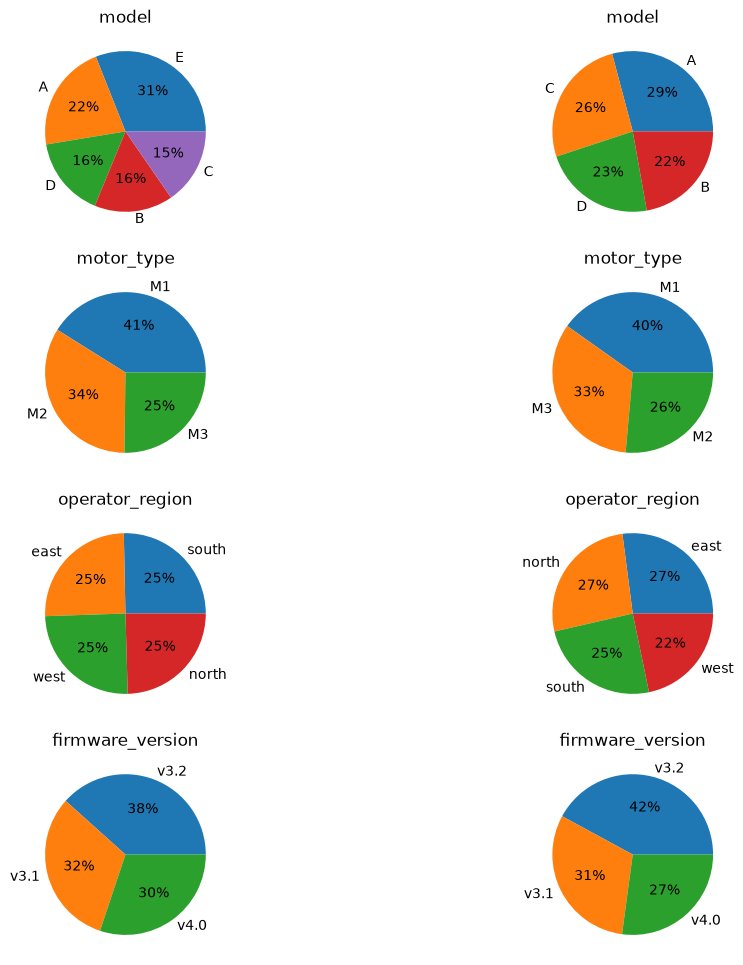

In [4]:
categorical_columns = ["model", "motor_type", "operator_region", "firmware_version"]
fig, full_axes = plt.subplots(4,2,figsize=(12,12))
for axes, category in zip(full_axes, categorical_columns):
    for (ax,dataset) in zip( axes, [test, train]):
        dataset[category].value_counts().plot.pie(autopct="%1.0f%%", ax=ax)
        ax.set_title(f"{category}")

Text(0.5, 1.0, 'Failure Modes')

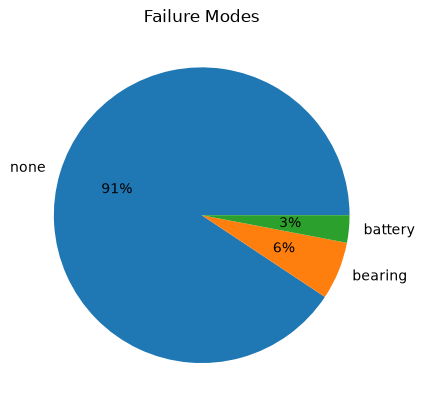

In [5]:
train.failure_mode.value_counts().plot.pie("Failure by Category", autopct="%1.0f%%")
plt.title("Failure Modes")

array([[<Axes: title={'center': 'flight_id'}>,
        <Axes: title={'center': 'battery_capacity_mAh'}>,
        <Axes: title={'center': 'max_payload_g'}>,
        <Axes: title={'center': 'propeller_in'}>],
       [<Axes: title={'center': 'manufacture_batch'}>,
        <Axes: title={'center': 'flight_index'}>,
        <Axes: title={'center': 'payload_g'}>,
        <Axes: title={'center': 'ambient_temp_C'}>],
       [<Axes: title={'center': 'wind_speed_ms'}>,
        <Axes: title={'center': 'flight_duration_min'}>,
        <Axes: title={'center': 'avg_throttle'}>,
        <Axes: title={'center': 'num_aggressive_maneuvers'}>],
       [<Axes: title={'center': 'cumulative_flight_hours'}>,
        <Axes: title={'center': 'battery_cycles'}>,
        <Axes: title={'center': 'failure_within_horizon'}>, <Axes: >]],
      dtype=object)

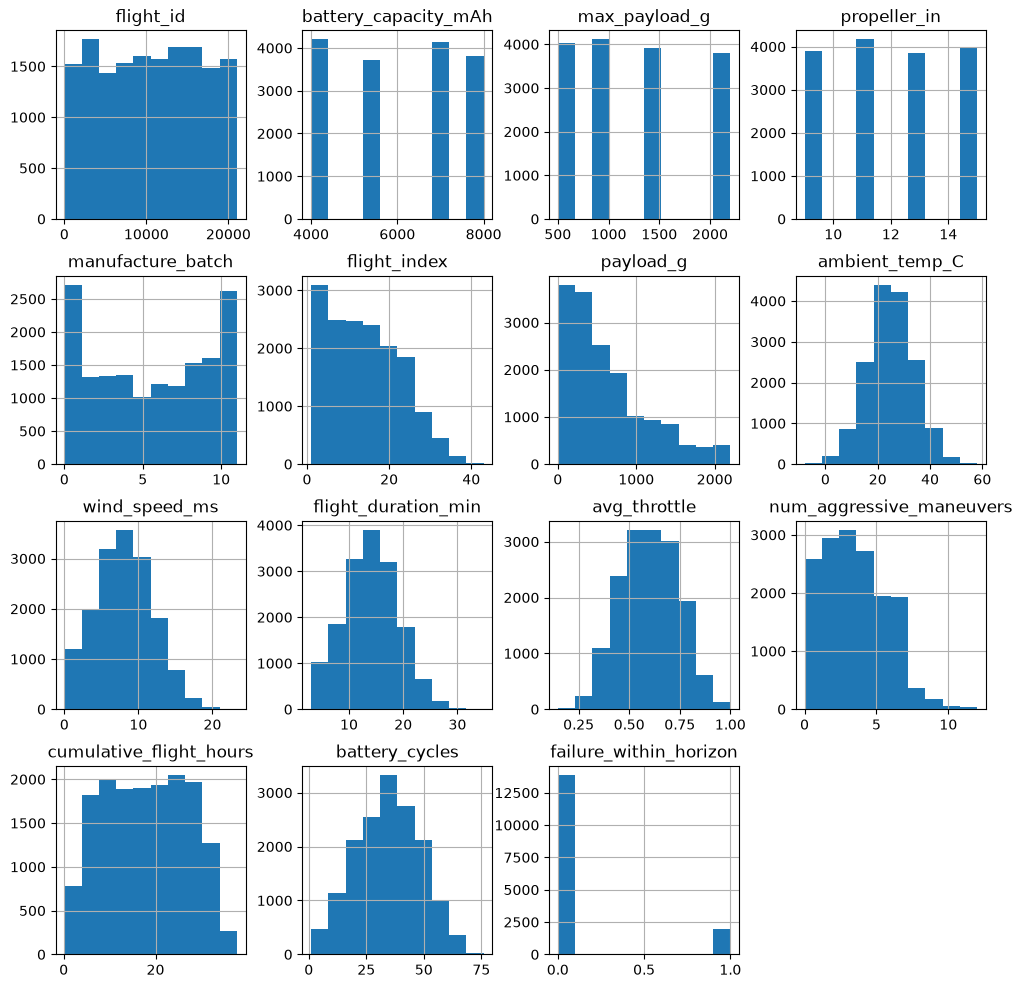

In [ ]:
train.hist(figsize=(12, 12))

<Axes: >

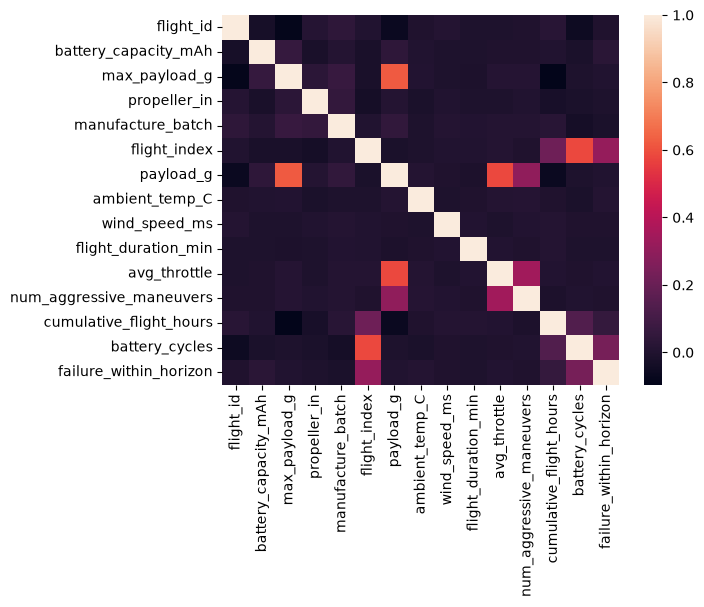

In [ ]:
sns.heatmap(train[train.select_dtypes("number").columns].corr())

Text(0.5, 1.0, 'Number of flights per drone')

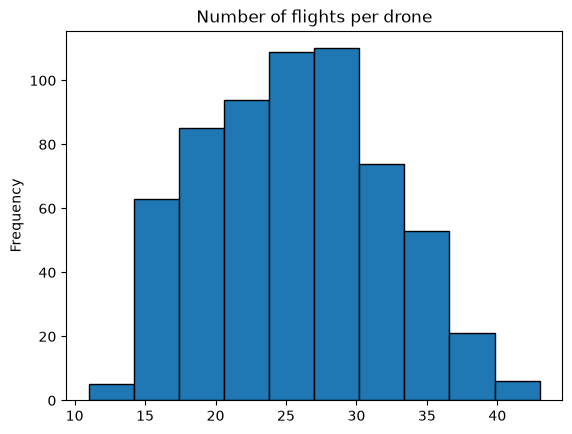

In [ ]:
train.groupby("drone_id")["flight_id"].count().plot.hist(edgecolor="black")
plt.title("Number of flights per drone")

In [ ]:
train[ train.drone_id == "D1004" ][["failure_mode", "flight_id", "failure_within_horizon", "battery_cycles"]]

,failure_mode,flight_id,failure_within_horizon,battery_cycles
45,none,105,0,11
46,none,106,0,12
47,none,107,0,13
48,none,108,0,14
49,none,109,0,15
50,none,110,0,16
51,none,111,0,17
52,none,112,0,18
53,none,113,0,19
54,none,114,0,20


<Axes: >

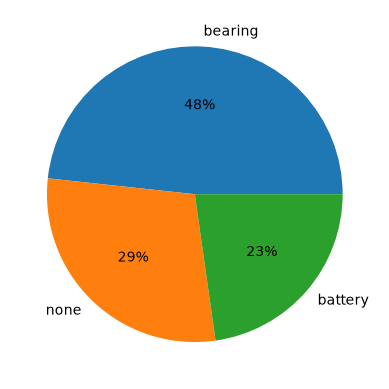

In [ ]:
df[ df.failure_within_horizon == 1 ].failure_mode.value_counts().plot.pie(autopct="%1.0f%%")

In [ ]:
possibilities = train.groupby("drone_id").failure_mode.agg(set)

In [ ]:
(possibilities == {"bearing", "battery"}).sum()


np.int64(0)

In [ ]:
train[ train.drone_id == "D1004" ][[ "flight_id", "failure_within_horizon", "cumulative_flight_hours", "battery_capacity_mAh"]]

,flight_id,failure_within_horizon,cumulative_flight_hours,battery_capacity_mAh
45,105,0,20.19,4000
46,106,0,20.38,4000
47,107,0,20.70,4000
48,108,0,20.97,4000
49,109,0,21.30,4000
50,110,0,21.46,4000
51,111,0,21.71,4000
52,112,0,21.90,4000
53,113,0,21.98,4000
54,114,0,22.39,4000


In [ ]:
train[ train.drone_id == "D1004" ][[ "flight_id", "failure_within_horizon", "payload_g"]]

,flight_id,failure_within_horizon,payload_g
45,105,0,1773.1
46,106,0,244.9
47,107,0,203.7
48,108,0,1664.6
49,109,0,1499.4
50,110,0,1707.7
51,111,0,153.0
52,112,0,1405.6
53,113,0,504.4
54,114,0,1804.5


In [ ]:
train.groupby("drone_id").firmware_version.agg(set).apply(lambda s: len(s)).unique()

array([1])

In [ ]:
train[ train.drone_id == "D1000" ][ [""] ] 

,flight_id,drone_id,model,motor_type,firmware_version,battery_capacity_mAh,max_payload_g,propeller_in,manufacture_batch,operator_region,...,payload_g,ambient_temp_C,wind_speed_ms,flight_duration_min,avg_throttle,num_aggressive_maneuvers,cumulative_flight_hours,battery_cycles,failure_mode,failure_within_horizon
0,0,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,69.2,18.75,15.63,14.85,0.341,0,16.44,25,none,0
1,1,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,728.1,29.90,5.97,10.59,0.762,1,16.61,26,none,0
2,2,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,868.3,30.96,12.01,18.62,0.928,2,16.92,27,none,0
3,3,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,840.1,25.32,10.94,17.53,0.920,5,17.21,28,none,0
4,4,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,19.3,28.58,7.10,21.09,0.434,1,17.57,29,none,0
5,5,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,853.1,20.48,16.06,9.29,0.748,8,17.72,30,none,0
6,6,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,237.3,26.98,2.30,10.02,0.626,4,17.89,31,none,0
7,7,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,320.2,12.23,14.38,15.88,0.597,3,18.15,32,none,0
8,8,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,657.8,19.07,6.55,10.49,0.594,0,18.33,33,none,1
9,9,D1000,C,M3,v3.1,5200,900.0,11.0,3,east,...,388.0,32.66,10.22,8.27,0.477,4,18.46,34,none,0


In [ ]:

train = train.sort_values(['drone_id', 'flight_id']).reset_index(drop=True)

roll_features = ['payload_g', 'ambient_temp_C', 'wind_speed_ms', 'flight_duration_min', 
                 'avg_throttle', 'num_aggressive_maneuvers']

def slope(x):
    return x[-1] - x[0]

def rolling_stats(group, window):
    # group is one drone's flights as a dataframe
    # select only the columns we want to roll over
    r = group[roll_features].rolling(window, min_periods=1)
    
    mean = r.mean().add_suffix(f'_mean_{window}')
    std  = r.std().add_suffix(f'_std_{window}')
    # slp  = r.apply(slope).add_suffix(f'_slope_{window}')
    
    return pd.concat([mean, std], axis=1)

windows = [3, 5]

# groupby splits df into one sub-dataframe per drone
# group_keys=False stops pandas adding drone_id as an extra index level
# for each drone we compute rolling stats at each window size
# pd.concat with axis=1 joins the window results side by side
# the outer apply stitches all drones back into one dataframe
rolled = train.groupby('drone_id', group_keys=False).apply(
    lambda g: pd.concat([rolling_stats(g, w) for w in windows], axis=1)
)

# add a column counting how many flights this drone has had so far
# the model can use this to know how much history it's working with
train['flights_so_far'] = train.groupby('drone_id').cumcount() + 1

# concat joins the rolled feature columns onto df by index alignment
train = pd.concat([train, rolled], axis=1)

,payload_g_mean_3,ambient_temp_C_mean_3,wind_speed_ms_mean_3,flight_duration_min_mean_3,avg_throttle_mean_3,num_aggressive_maneuvers_mean_3,payload_g_std_3,ambient_temp_C_std_3,wind_speed_ms_std_3,flight_duration_min_std_3,...,wind_speed_ms_mean_5,flight_duration_min_mean_5,avg_throttle_mean_5,num_aggressive_maneuvers_mean_5,payload_g_std_5,ambient_temp_C_std_5,wind_speed_ms_std_5,flight_duration_min_std_5,avg_throttle_std_5,num_aggressive_maneuvers_std_5
0,69.200000,18.750000,15.630000,14.850000,0.341000,0.000000,NaN,NaN,NaN,NaN,...,15.630000,14.850000,0.34100,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,398.650000,24.325000,10.800000,12.720000,0.551500,0.500000,465.912658,7.884241,6.830652,3.012275,...,10.800000,12.720000,0.55150,0.5,465.912658,7.884241,6.830652,3.012275,0.297692,0.707107
2,555.200000,26.536667,11.203333,14.686667,0.677000,1.000000,426.686079,6.764247,4.880260,4.017491,...,11.203333,14.686667,0.67700,1.0,426.686079,6.764247,4.880260,4.017491,0.302590,1.000000
3,812.166667,28.726667,9.640000,15.580000,0.870000,2.666667,74.156681,2.997488,3.223027,4.355697,...,11.137500,15.397500,0.73775,2.0,376.385453,5.556386,3.986890,3.575093,0.275323,2.160247
4,575.900000,28.286667,10.016667,19.080000,0.760667,2.666667,482.235917,2.831419,2.581944,1.824034,...,10.330000,16.536000,0.67700,1.8,424.228311,4.925162,3.896377,4.008351,0.274418,1.923538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15867,160.200000,27.843333,5.816667,14.083333,0.544667,2.000000,102.998107,3.828059,5.577727,4.544242,...,7.342000,13.588000,0.60440,2.8,162.406567,8.459248,4.622009,5.114550,0.084769,1.483240
15868,155.266667,25.976667,5.776667,14.266667,0.548667,1.666667,102.192677,0.697161,5.512988,4.664293,...,8.100000,13.202000,0.56760,2.0,123.555809,8.564813,5.034883,4.719075,0.059982,1.000000
15869,201.233333,29.306667,8.113333,13.176667,0.604000,3.666667,174.427788,5.147168,3.478065,3.869862,...,7.402000,14.574000,0.57920,2.8,126.609707,4.410082,4.706349,3.381971,0.085260,2.489980
15870,296.133333,28.253333,7.373333,15.576667,0.657667,4.333333,120.064247,6.335971,4.597797,1.239287,...,5.546000,14.614000,0.61720,3.4,136.507044,4.710764,4.333714,3.402841,0.094658,2.607681
